In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)

In [26]:
# Change this path if your CSV file is in another folder.
df = pd.read_csv("C:/Users/Prath/Downloads/heart_disease_uci.csv")

In [27]:
# 2. Quick look at the data
# -----------------------------
print("First 5 rows:")
print(df.head())
print("\nDataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic information:")
print(df.info())


First 5 rows:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal  

In [28]:
df = df.rename(columns={"num": "target"})


Target distribution:
target
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


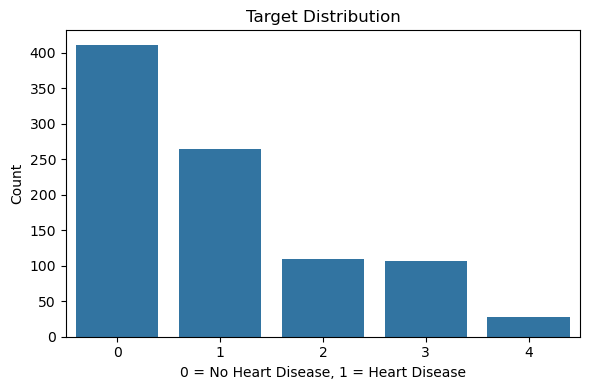

In [29]:
# Target column is usually named 'target' in this dataset.
print("\nTarget distribution:")
print(df["target"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.xlabel("0 = No Heart Disease, 1 = Heart Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


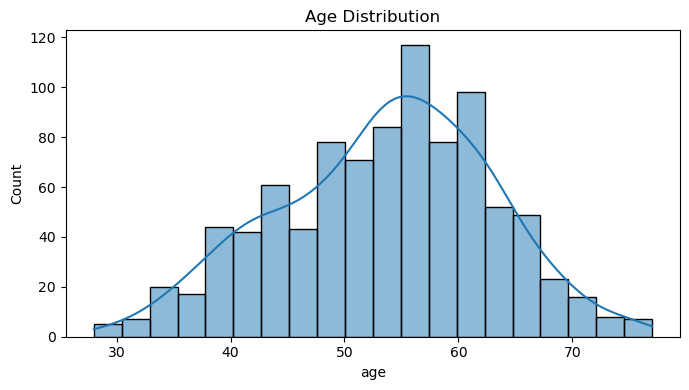

In [30]:
# Age distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.tight_layout()
plt.show()

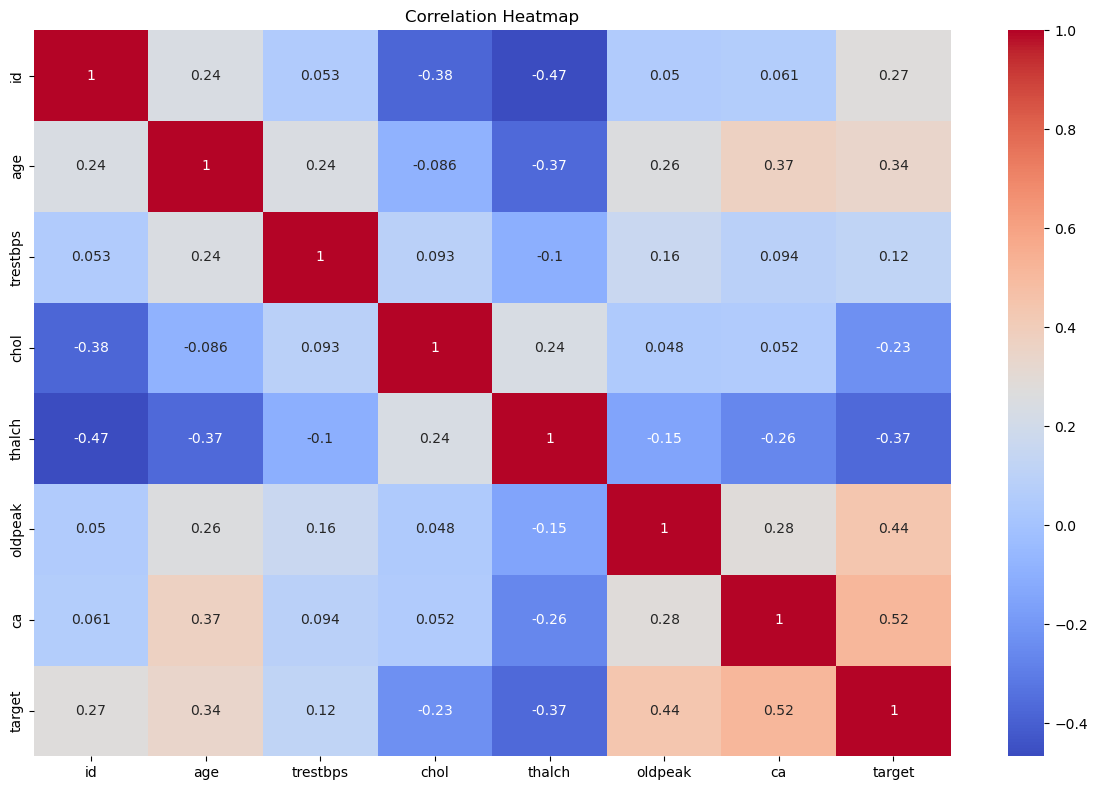

In [31]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [37]:
# Fill missing numeric values with mean
df = df.fillna(df.mean(numeric_only=True))

In [38]:


# Create label encoder object
le = LabelEncoder()

# Convert all text columns into numbers
for column in df.columns:
    
    # Check if column type is object/text
    if df[column].dtype == 'object':
        
        # Apply label encoding
        df[column] = le.fit_transform(df[column])

# Check updated data
print(df.head())

   id  age  sex  dataset  cp  trestbps   chol  fbs  restecg  thalch  exang  \
0   1   63    1        0   3     145.0  233.0    1        0   150.0      0   
1   2   67    1        0   0     160.0  286.0    0        0   108.0      1   
2   3   67    1        0   0     120.0  229.0    0        0   129.0      1   
3   4   37    1        0   2     130.0  250.0    0        1   187.0      0   
4   5   41    0        0   1     130.0  204.0    0        0   172.0      0   

   oldpeak  slope   ca  thal  target  
0      2.3      0  0.0     0       0  
1      1.5      1  3.0     1       2  
2      2.6      1  2.0     2       1  
3      3.5      0  0.0     1       0  
4      1.4      2  0.0     1       0  


In [43]:
# Convert target into binary values
# 0 = No Heart Disease
# 1 = Heart Disease

df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

In [44]:
X = df.drop("target", axis=1)
y = df["target"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [46]:
# Standardize only for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [47]:
# -----------------------------
# 5. Train Logistic Regression
# -----------------------------

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train_scaled, y_train)

# Predict values
y_pred_log = log_model.predict(X_test_scaled)

# Predict probability
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Accuracy and AUC
log_acc = accuracy_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

# Print results
print("\nLogistic Regression Results")
print("Accuracy:", round(log_acc, 4))
print("AUC Score:", round(log_auc, 4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_log))


Logistic Regression Results
Accuracy: 0.8533
AUC Score: 0.9181

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        82
           1       0.85      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

Confusion Matrix
[[66 16]
 [11 91]]


In [51]:
# -----------------------------
# Decision Tree Model
# -----------------------------

dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Probability
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Accuracy
dt_acc = accuracy_score(y_test, y_pred_dt)

# AUC Score
dt_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Accuracy:", dt_acc)
print("Decision Tree AUC:", dt_auc)

Decision Tree Accuracy: 0.8369565217391305
Decision Tree AUC: 0.8314203730272597


In [52]:
# -----------------------------
# 7. Train Random Forest
# -----------------------------

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict values
y_pred_rf = rf_model.predict(X_test)

# Predict probability
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Accuracy and AUC
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

# Print results
print("\nRandom Forest Results")
print("Accuracy:", round(rf_acc, 4))
print("AUC Score:", round(rf_auc, 4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Results
Accuracy: 0.8859
AUC Score: 0.9518

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.84      0.87        82
           1       0.88      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

Confusion Matrix
[[69 13]
 [ 8 94]]


In [53]:
# -----------------------------
# 8. Compare Model Performance
# -----------------------------

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [log_acc, dt_acc, rf_acc],
    "AUC Score": [log_auc, dt_auc, rf_auc]
})

print("\nModel Comparison")
print(results)


Model Comparison
                 Model  Accuracy  AUC Score
0  Logistic Regression  0.853261   0.918101
1        Decision Tree  0.836957   0.831420
2        Random Forest  0.885870   0.951758


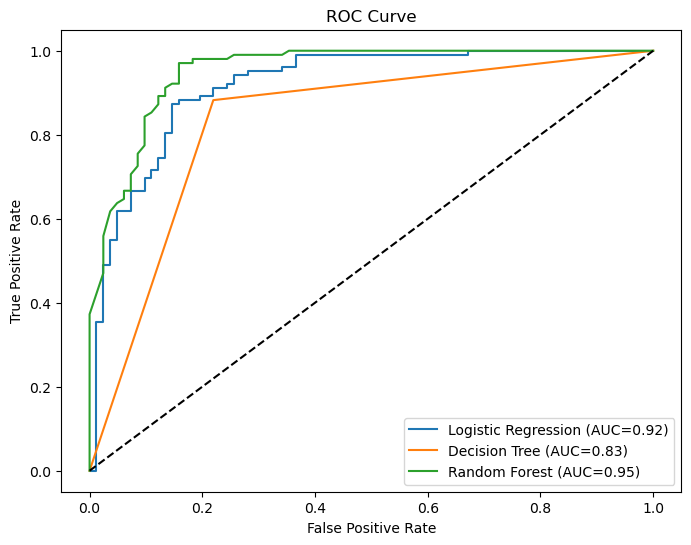

In [54]:
# -----------------------------
# 9. ROC Curve
# -----------------------------

plt.figure(figsize=(8,6))

# Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={log_auc:.2f})")

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={dt_auc:.2f})")

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.2f})")

# Random line
plt.plot([0,1], [0,1], "k--")

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()


Feature Importance
     Feature  Importance
0         id    0.234090
4         cp    0.111100
1        age    0.074734
9     thalch    0.071488
6       chol    0.068905
11   oldpeak    0.066866
3    dataset    0.063655
10     exang    0.063373
13        ca    0.051836
12     slope    0.049903
5   trestbps    0.048520
14      thal    0.036932
8    restecg    0.021533
2        sex    0.021283
7        fbs    0.015782


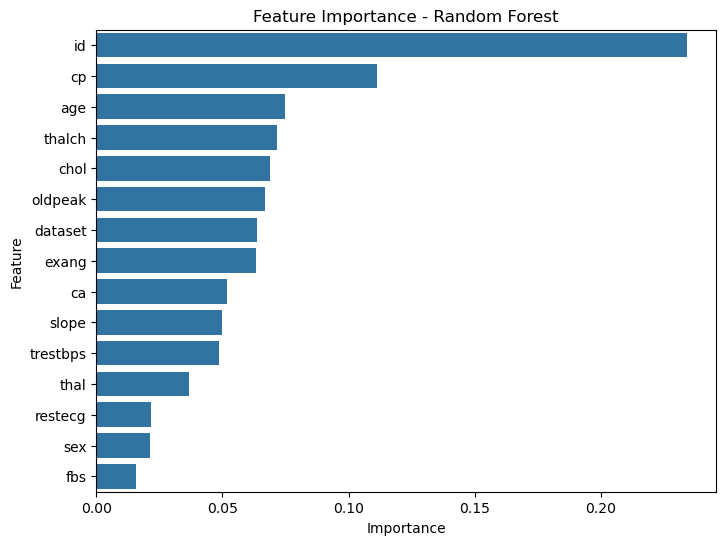

In [55]:
# -----------------------------
# 10. Feature Importance
# -----------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort values
importance = importance.sort_values(by="Importance", ascending=False)

print("\nFeature Importance")
print(importance)

# Plot graph
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance - Random Forest")

plt.show()